In [1]:
pip install pandas matplotlib seaborn mysql-connector-python

   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   -- ------------------------------------- 1.0/16.5 MB 7.6 MB/s eta 0:00:03
   ---- ----------------------------------- 1.8/16.5 MB 4.9 MB/s eta 0:00:03
   ------ --------------------------------- 2.6/16.5 MB 4.6 MB/s eta 0:00:04
   -------- ------------------------------- 3.4/16.5 MB 4.3 MB/s eta 0:00:04
   --------- ------------------------------ 3.9/16.5 MB 4.3 MB/s eta 0:00:03
   ------------ --------------------------- 5.0/16.5 MB 4.2 MB/s eta 0:00:03
   ------------- -------------------------- 5.5/16.5 MB 4.2 MB/s eta 0:00:03
   ------------- -------------------------- 5.5/16.5 MB 4.2 MB/s eta 0:00:03
   ------------- -------------------------- 5.5/16.5 MB 4.2 MB/s eta 0:00:03
   ------------- -------------------------- 5.5/16.5 MB 4.2 MB/s eta 0:00:03
   ------------- -------------------------- 5.5/16.5 MB 4.2 MB/s eta 0:00:03
   ----------

In [2]:
import mysql.connector
import pandas as pd

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root123",   # change this
    database="risk_analysis"
)

# Load data
query = "SELECT * FROM risk_data"
df = pd.read_sql(query, conn)

print(df.head())

            Date Transaction_Type  Transaction_Amount  \
0     18-08-2024           Refund              952.11   
1  18-08-2024+B3            Debit             3293.29   
2     30-04-2024            Debit             2849.97   
3     23-03-2024           Refund             9813.53   
4     03-07-2024           Credit             1228.69   

                     Region Payment_Method  Fraud_Flag  Likelihood  Impact  \
0             Garcia-Gordon           Cash           0           2       2   
1  Heath, Pena and Buchanan           Cash           1           5       3   
2                  Pham PLC           Cash           0           2       2   
3  Levine, Long and Stewart           Cash           0           2       5   
4                   Lee LLC  Bank Transfer           0           2       2   

   Risk_Score Risk_Level  
0           4        Low  
1          15       High  
2           4        Low  
3          10     Medium  
4           4        Low  


C:\Users\Ananya\AppData\Local\Temp\ipykernel_20068\3484964421.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


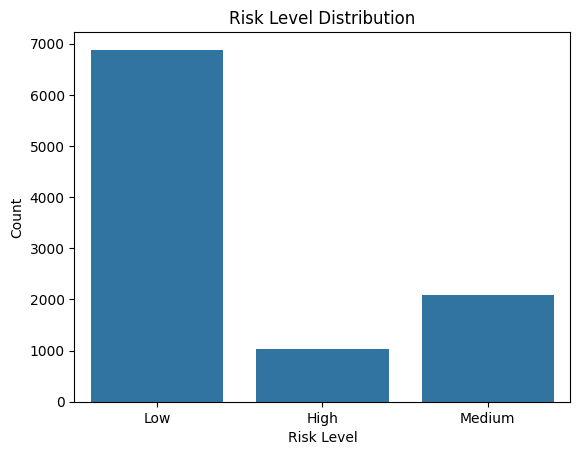

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Risk_Level', data=df)
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

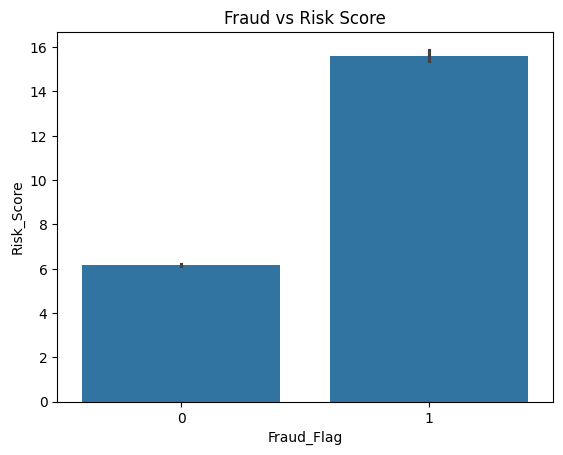

In [4]:
sns.barplot(x='Fraud_Flag', y='Risk_Score', data=df)
plt.title("Fraud vs Risk Score")
plt.show()

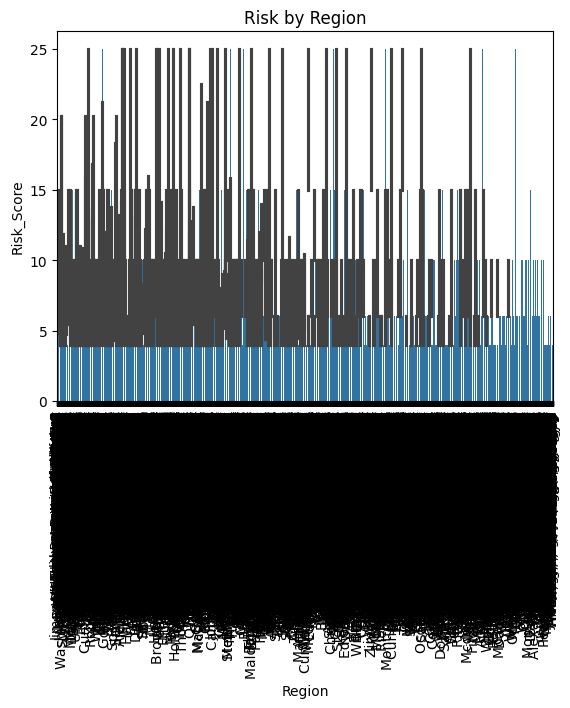

In [5]:
sns.barplot(x='Region', y='Risk_Score', data=df)
plt.title("Risk by Region")
plt.xticks(rotation=90)
plt.show()

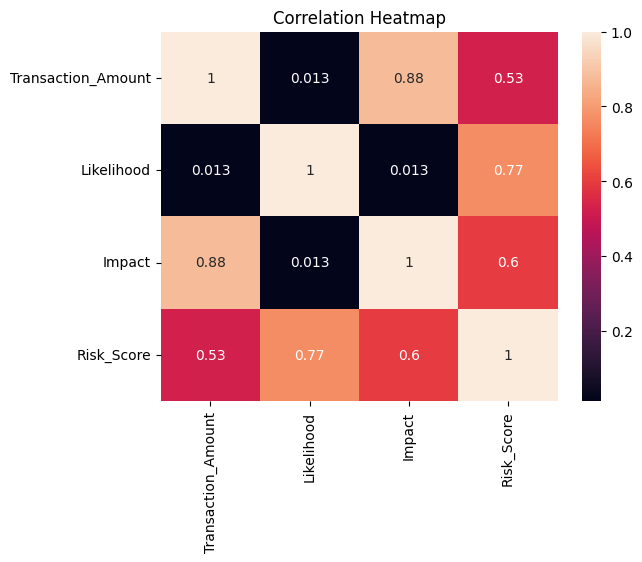

In [6]:
sns.heatmap(df[['Transaction_Amount','Likelihood','Impact','Risk_Score']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [8]:
# Clean Date column
df['Date'] = df['Date'].astype(str)
df['Date'] = df['Date'].str.replace(r'\+.*', '', regex=True)

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(df['Date'].head())

0   2024-08-18
1   2024-08-18
2   2024-04-30
3   2024-03-23
4   2024-07-03
Name: Date, dtype: datetime64[ns]


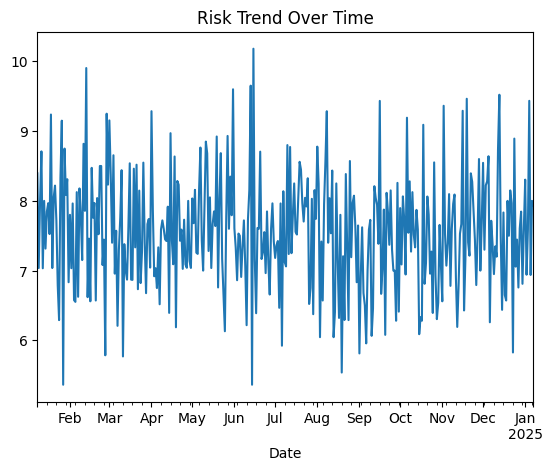

In [9]:
df.groupby('Date')['Risk_Score'].mean().plot()
plt.title("Risk Trend Over Time")
plt.show()

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [11]:
le = LabelEncoder()

df['Transaction_Type'] = le.fit_transform(df['Transaction_Type'])
df['Region'] = le.fit_transform(df['Region'])
df['Payment_Method'] = le.fit_transform(df['Payment_Method'])
df['Risk_Level'] = le.fit_transform(df['Risk_Level'])

In [12]:
X = df[['Transaction_Amount', 'Transaction_Type', 'Region', 
        'Payment_Method', 'Likelihood', 'Impact', 'Risk_Score']]

y = df['Fraud_Flag']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\Ananya\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [15]:
y_pred = model.predict(X_test)

In [16]:

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[1702    0]
 [   0  298]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1702
           1       1.00      1.00      1.00       298

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [17]:
sample = [[5000, 1, 2, 0, 4, 5, 20]]  # example values
prediction = model.predict(sample)

print("Fraud Prediction:", prediction)

Fraud Prediction: [1]


C:\Users\Ananya\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


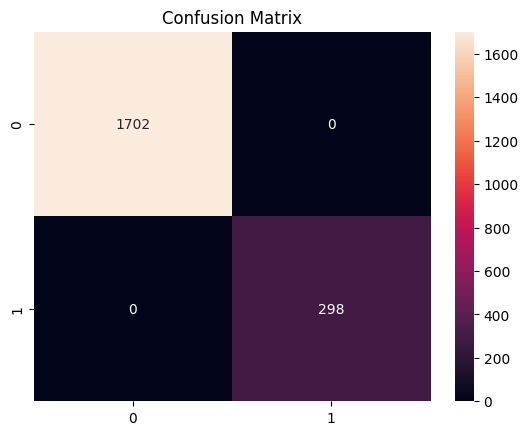

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()